In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Ce script parcourt l’ensemble des images du dataset (organisées par personne) afin de vérifier si elles sont valides.  
Chaque image est ouverte avec la bibliothèque PIL :

- Si l’image s’ouvre correctement → elle est conservée  
- Si une erreur se produit → elle est considérée comme corrompue et supprimée automatiquement

In [2]:
import os
from PIL import Image
from google.colab import drive
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# Monter Google Drive
drive.mount('/content/drive')

# Configuration
DATASET_PATH = "/content/drive/MyDrive/CNN Data/mfr2_sorted"
MAX_WORKERS = 8  # Nombre de threads parallèles

def check_image(img_path):
    """Vérifie si une image est corrompue."""
    try:
        with Image.open(img_path) as img:
            img.verify()
        return img_path, True
    except Exception:
        return img_path, False

def get_all_images(dataset_path):
    """Récupère tous les chemins d'images de façon récursive."""
    images = []
    valid_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}

    for root, _, files in os.walk(dataset_path):
        for img_name in files:
            if os.path.splitext(img_name)[1].lower() in valid_extensions:
                images.append(os.path.join(root, img_name))

    return images

# Collecter toutes les images
print("📂 Scan des images...")
all_images = get_all_images(DATASET_PATH)
total_images = len(all_images)
print(f"   {total_images} images trouvées\n")

# Vérification parallèle avec barre de progression
corrupted = []

print("🔍 Vérification en cours...")
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(check_image, img): img for img in all_images}

    for future in tqdm(as_completed(futures), total=total_images, unit="img"):
        img_path, is_valid = future.result()
        if not is_valid:
            corrupted.append(img_path)

# Suppression des images corrompues
for img_path in corrupted:
    print(f"❌ Supprimé: {img_path}")
    os.remove(img_path)

# Résumé
print("\n" + "="*50)
print("✅ Nettoyage terminé")
print(f"   Total images   : {total_images}")
print(f"   Images valides : {total_images - len(corrupted)}")
print(f"   Supprimées     : {len(corrupted)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Scan des images...
   269 images trouvées

🔍 Vérification en cours...


100%|██████████| 269/269 [00:09<00:00, 29.18img/s]


✅ Nettoyage terminé
   Total images   : 269
   Images valides : 269
   Supprimées     : 0


Vérification et conversion RGB car Les CNN ou modèles de contrastive learning que vous allez utiliser sont conçus pour traiter des images RGB

In [3]:
import os
from PIL import Image
from google.colab import drive
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# Monter Google Drive
drive.mount('/content/drive')

# Configuration
DATASET_PATH = "/content/drive/MyDrive/CNN Data/mfr2_sorted"
MAX_WORKERS = 8

def convert_image(img_path):
    """Convertit une image en RGB si nécessaire."""
    try:
        with Image.open(img_path) as img:
            if img.mode != 'RGB':
                img.convert('RGB').save(img_path)
                return 'converted'
            return 'ok'
    except Exception as e:
        return f'error: {e}'

def get_all_images(dataset_path):
    """Récupère tous les chemins d'images de façon récursive."""
    images = []
    valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}

    for root, _, files in os.walk(dataset_path):
        for img_name in files:
            if os.path.splitext(img_name)[1].lower() in valid_ext:
                images.append(os.path.join(root, img_name))

    return images

# Collecter les images
print("📂 Scan des images...")
all_images = get_all_images(DATASET_PATH)
total = len(all_images)
print(f"   {total} images trouvées\n")

# Conversion parallèle
converted = 0
errors = 0

print("🔄 Conversion en cours...")
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(convert_image, img): img for img in all_images}

    for future in tqdm(as_completed(futures), total=total, unit="img"):
        result = future.result()
        if result == 'converted':
            converted += 1
        elif result.startswith('error'):
            errors += 1
            print(f"\n {futures[future]}: {result}")

# Résumé
print("\n" + "="*50)
print("✅ Conversion terminée")
print(f"   Total images  : {total}")
print(f"   Déjà RGB      : {total - converted - errors}")
print(f"   Converties    : {converted}")
print(f"   Erreurs       : {errors}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Scan des images...
   269 images trouvées

🔄 Conversion en cours...


100%|██████████| 269/269 [00:00<00:00, 300.92img/s]


✅ Conversion terminée
   Total images  : 269
   Déjà RGB      : 269
   Converties    : 0
   Erreurs       : 0


Vérifier la taille et supprimer les images trop petites car on veut éviter les images trop petites (<100×100 px), car elles ne contiennent pas assez d’information pour le modèle

In [4]:
import os
from PIL import Image
from google.colab import drive

# Monter Google Drive
drive.mount('/content/drive')

# Chemin du dataset sur Drive
dataset_path = "/content/drive/MyDrive/CNN Data/mfr2_sorted"

# Paramètres
min_size = 100  # taille minimale recommandée
small_count = 0
total_images = 0

# Parcours des dossiers par personne
for root, _, files in os.walk(dataset_path):
    for img_name in files:
        if os.path.splitext(img_name)[1].lower() not in {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}:
            continue

        img_path = os.path.join(root, img_name)
        total_images += 1

        try:
            with Image.open(img_path) as img:
                width, height = img.size

                # Supprimer si trop petite
                if width < min_size or height < min_size:
                    print(f"❌ Trop petite : {img_path} ({width}x{height})")
                    small_count += 1
                    os.remove(img_path)

        except Exception as e:
            print(f"⚠ Erreur ouverture image {img_path} : {e}")

print("\n✅ Vérification terminée")
print(f"Images analysées : {total_images}")
print(f"Images supprimées (trop petites) : {small_count}")
print(f"Images restantes : {total_images - small_count}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Vérification terminée
Images analysées : 269
Images supprimées (trop petites) : 0
Images restantes : 269


crop


In [5]:
!pip install mtcnn

import os
from pathlib import Path
import numpy as np
from PIL import Image
from mtcnn import MTCNN
from google.colab import drive
import shutil



# Sous-dossier à tester
source_root = Path("/content/drive/MyDrive/CNN Data/mfr2_sorted")
person_drive_path = next((p for p in sorted(source_root.iterdir()) if p.is_dir()), None)
if person_drive_path is None:
    raise FileNotFoundError(f'No person folder found in {source_root}')

# Copier en local pour accélérer
person_local_path = Path("/content/temp_person")
if person_local_path.exists():
    shutil.rmtree(person_local_path)
shutil.copytree(person_drive_path, person_local_path)

# Dossier pour sauvegarder les crops
output_path = f"/content/drive/MyDrive/CNN Data/mfr2_sorted_crops/{person_drive_path.name}"
os.makedirs(output_path, exist_ok=True)

detector = MTCNN()

# Optionnel : ne traiter que les 50 premières images pour test
MAX_IMAGES = 50
processed = 0

image_paths = [p for p in person_local_path.rglob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}]

for img_path in image_paths:
    if processed >= MAX_IMAGES:
        break

    try:
        img = Image.open(img_path).convert('RGB')
        img_array = np.array(img)

        result = detector.detect_faces(img_array)

        if result:
            x, y, w, h = result[0]['box']
            x, y = max(0, x), max(0, y)
            face = img.crop((x, y, x + w, y + h))
            face.save(os.path.join(output_path, img_path.name))
            print(f"✅ Face cropped: {img_path.name}")
        else:
            print(f"⚠ Pas de visage détecté: {img_path.name}")

        processed += 1
    except Exception as e:
        print(f"Erreur sur {img_path.name}: {e}")

print("\n✅ Crop terminé pour le test !")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.4 MB/s eta 0:00:00
✅ Face cropped: AdrianDunbar_0004.png
✅ Face cropped: AdrianDunbar_0002.png
✅ Face cropped: AdrianDunbar_0003.png
✅ Face cropped: AdrianDunbar_0001.png

✅ Crop terminé pour le test !


In [6]:
import os
from tqdm import tqdm
from PIL import Image
import numpy as np
from mtcnn import MTCNN
from concurrent.futures import ThreadPoolExecutor
import time

DATASET_PATH = "/content/drive/MyDrive/CNN Data/mfr2_sorted"
OUTPUT_PATH = "/content/drive/MyDrive/CNN Data/mfr2_sorted_crops_all"

MAX_WORKERS = 6
detector = MTCNN()

# =========================
def process_image(task):
    img_path, person, subfolder, img_name = task

    try:
        img = Image.open(img_path).convert("RGB")
        img = img.resize((320, 320))

        results = detector.detect_faces(np.array(img))

        if not results:
            return "no_face"

        best = max(results, key=lambda x: x["confidence"])

        x, y, w, h = best["box"]
        x, y = max(0, x), max(0, y)

        face = img.crop((x, y, x + w, y + h))

        out_dir = os.path.join(OUTPUT_PATH, person, subfolder)
        os.makedirs(out_dir, exist_ok=True)

        out_path = os.path.join(out_dir, img_name)
        face.save(out_path)

        return "success"

    except:
        return "error"


# =========================
print("📂 SCAN COMPLET DU DATASET...")

tasks = []

for person in sorted(os.listdir(DATASET_PATH)):   # 🔥 sorted pour stabilité
    person_path = os.path.join(DATASET_PATH, person)

    if not os.path.isdir(person_path):
        continue

    for subfolder in sorted(os.listdir(person_path)):
        sub_path = os.path.join(person_path, subfolder)

        if not os.path.isdir(sub_path):
            continue

        for img in os.listdir(sub_path):
            if img.lower().endswith((".jpg", ".jpeg", ".png")):

                img_path = os.path.join(sub_path, img)

                tasks.append((img_path, person, subfolder, img))

print("Total images:", len(tasks))


# =========================
stats = {"success":0, "no_face":0, "error":0}

print("🚀 Processing...")

start = time.time()

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    for result in tqdm(executor.map(process_image, tasks), total=len(tasks)):
        if result in stats:
            stats[result] += 1


# =========================
print("\nRESULTS:")
print(stats)
print("Time:", (time.time()-start)/60, "min")

📂 SCAN COMPLET DU DATASET...
Total images: 269
🚀 Processing...


100%|██████████| 269/269 [01:53<00:00,  2.37it/s]


RESULTS:
{'success': 254, 'no_face': 9, 'error': 6}
Time: 1.8956526080767313 min


apérs test je choisie mtcnn il est plus precis

In [7]:
import os
from tqdm import tqdm
from PIL import Image
import numpy as np
from mtcnn import MTCNN
from concurrent.futures import ThreadPoolExecutor
import time

DATASET_PATH = "/content/drive/MyDrive/CNN Data/mfr2_sorted"
OUTPUT_PATH = "/content/drive/MyDrive/CNN Data/mfr2_sorted_crops_all"

MAX_WORKERS = 6
detector = MTCNN()

# =========================
def process_image(task):
    img_path, person, subfolder, img_name = task

    try:
        img = Image.open(img_path).convert("RGB")
        img = img.resize((320, 320))

        results = detector.detect_faces(np.array(img))

        if not results:
            return "no_face"

        best = max(results, key=lambda x: x["confidence"])

        x, y, w, h = best["box"]
        x, y = max(0, x), max(0, y)

        face = img.crop((x, y, x + w, y + h))

        out_dir = os.path.join(OUTPUT_PATH, person, subfolder)
        os.makedirs(out_dir, exist_ok=True)

        out_path = os.path.join(out_dir, img_name)
        face.save(out_path)

        return "success"

    except:
        return "error"


# =========================
print("📂 SCAN COMPLET DU DATASET...")

tasks = []

for person in sorted(os.listdir(DATASET_PATH)):   # 🔥 sorted pour stabilité
    person_path = os.path.join(DATASET_PATH, person)

    if not os.path.isdir(person_path):
        continue

    for subfolder in sorted(os.listdir(person_path)):
        sub_path = os.path.join(person_path, subfolder)

        if not os.path.isdir(sub_path):
            continue

        for img in os.listdir(sub_path):
            if img.lower().endswith((".jpg", ".jpeg", ".png")):

                img_path = os.path.join(sub_path, img)

                tasks.append((img_path, person, subfolder, img))

print("Total images:", len(tasks))


# =========================
stats = {"success":0, "no_face":0, "error":0}

print("🚀 Processing...")

start = time.time()

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    for result in tqdm(executor.map(process_image, tasks), total=len(tasks)):
        if result in stats:
            stats[result] += 1


# =========================
print("\nRESULTS:")
print(stats)
print("Time:", (time.time()-start)/60, "min")

📂 SCAN COMPLET DU DATASET...
Total images: 269
🚀 Processing...


100%|██████████| 269/269 [01:49<00:00,  2.47it/s]


RESULTS:
{'success': 254, 'no_face': 9, 'error': 6}
Time: 1.8174136757850647 min


In [8]:
import os
from PIL import Image
from google.colab import drive

drive.mount('/content/drive')

# ============================================
# CONFIGURATION
# ============================================
CROPPED_PATH = "/content/drive/MyDrive/CNN Data/mfr2_sorted_crops"
MIN_SIZE = 90

# ============================================
# COMPTAGE RAPIDE
# ============================================
total = 0
below_threshold = 0
size_distribution = {
    '<60': 0,
    '60-69': 0,
    '70-79': 0,
    '80-89': 0,
    '90-99': 0,
    '100-111': 0,
    '112+': 0
}

print(f"🔍 Vérification images < {MIN_SIZE}×{MIN_SIZE}...\n")

for person in os.listdir(CROPPED_PATH):
    person_path = os.path.join(CROPPED_PATH, person)
    if not os.path.isdir(person_path):
        continue

    for img_name in os.listdir(person_path):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        img_path = os.path.join(person_path, img_name)
        total += 1

        try:
            with Image.open(img_path) as img:
                w, h = img.size
                min_dim = min(w, h)

                # Compter si trop petite
                if w < MIN_SIZE or h < MIN_SIZE:
                    below_threshold += 1

                # Distribution
                if min_dim < 60:
                    size_distribution['<60'] += 1
                elif min_dim < 70:
                    size_distribution['60-69'] += 1
                elif min_dim < 80:
                    size_distribution['70-79'] += 1
                elif min_dim < 90:
                    size_distribution['80-89'] += 1
                elif min_dim < 100:
                    size_distribution['90-99'] += 1
                elif min_dim < 112:
                    size_distribution['100-111'] += 1
                else:
                    size_distribution['112+'] += 1
        except:
            pass

# ============================================
# RÉSULTATS
# ============================================
print("="*60)
print("📊 RÉSULTATS")
print("="*60)

print(f"\nTotal images        : {total}")
print(f"Images < {MIN_SIZE}×{MIN_SIZE}    : {below_threshold} ({below_threshold/total*100:.1f}%)")
print(f"Images ≥ {MIN_SIZE}×{MIN_SIZE}    : {total-below_threshold} ({(total-below_threshold)/total*100:.1f}%)")

print(f"\n📏 Distribution par taille (dimension min) :")
print("-"*60)
for size_range, count in size_distribution.items():
    pct = count/total*100 if total > 0 else 0
    bar = "█" * int(pct/2)
    print(f"{size_range:>10} px : {count:>5} ({pct:>5.1f}%) {bar}")

print("\n" + "="*60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 Vérification images < 90×90...

📊 RÉSULTATS

Total images        : 4
Images < 90×90    : 1 (25.0%)
Images ≥ 90×90    : 3 (75.0%)

📏 Distribution par taille (dimension min) :
------------------------------------------------------------
       <60 px :     0 (  0.0%) 
     60-69 px :     0 (  0.0%) 
     70-79 px :     1 ( 25.0%) ████████████
     80-89 px :     0 (  0.0%) 
     90-99 px :     3 ( 75.0%) █████████████████████████████████████
   100-111 px :     0 (  0.0%) 
      112+ px :     0 (  0.0%) 



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔍 Recherche d'images < 80×80...

✅ Trouvée : AdrianDunbar/AdrianDunbar_0002.png (76×105)

✅ 1 images trouvées



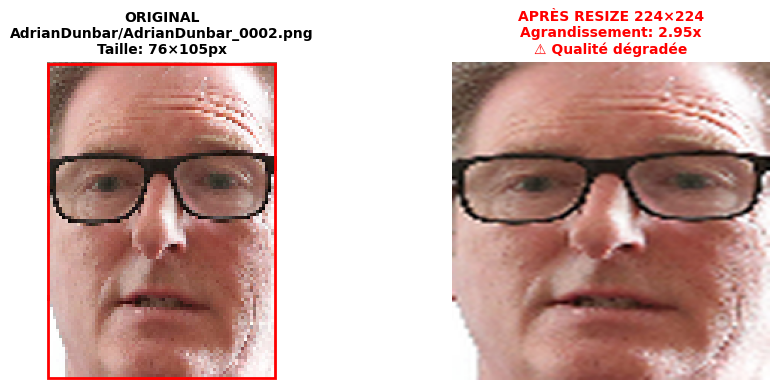


📊 ANALYSE

Image 1: AdrianDunbar_0002.png
  Taille originale  : 76×105 px
  Dimension min     : 76 px
  Agrandissement    : 2.95x
  Qualité après 224 : ⚠️ Médiocre

💡 RECOMMANDATION

Ces images sont TROP PETITES pour resize 224×224
→ Agrandissement excessif (>2.5x)
→ Pixelisation visible
→ Masques artificiels peu réalistes

✅ Il vaut mieux les REJETER


In [9]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

# ============================================
# CONFIGURATION
# ============================================
CROPPED_PATH = "/content/drive/MyDrive/CNN Data/mfr2_sorted_crops"
THRESHOLD = 80

# ============================================
# TROUVER 4 IMAGES < 80×80
# ============================================
small_images = []

print(f"🔍 Recherche d'images < {THRESHOLD}×{THRESHOLD}...\n")

for person in os.listdir(CROPPED_PATH):
    if len(small_images) >= 4:
        break

    person_path = os.path.join(CROPPED_PATH, person)
    if not os.path.isdir(person_path):
        continue

    for img_name in os.listdir(person_path):
        if len(small_images) >= 4:
            break

        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        img_path = os.path.join(person_path, img_name)

        try:
            with Image.open(img_path) as img:
                w, h = img.size
                if w < THRESHOLD or h < THRESHOLD:
                    small_images.append({
                        'path': img_path,
                        'size': (w, h),
                        'name': img_name,
                        'person': person
                    })
                    print(f"✅ Trouvée : {person}/{img_name} ({w}×{h})")
        except:
            pass

if len(small_images) == 0:
    print(f"❌ Aucune image < {THRESHOLD}×{THRESHOLD} trouvée")
else:
    print(f"\n✅ {len(small_images)} images trouvées\n")

# ============================================
# AFFICHAGE COMPARATIF
# ============================================
if len(small_images) > 0:
    fig, axes = plt.subplots(len(small_images), 2, figsize=(10, 4*len(small_images)))

    # Si une seule image, convertir axes en 2D
    if len(small_images) == 1:
        axes = axes.reshape(1, -1)

    for i, img_data in enumerate(small_images):
        # Charger image
        img_original = Image.open(img_data['path'])
        w, h = img_data['size']

        # Resize à 224×224
        img_resized = img_original.resize((224, 224), Image.LANCZOS)

        # Afficher original
        axes[i, 0].imshow(img_original)
        axes[i, 0].set_title(f"ORIGINAL\n{img_data['person']}/{img_data['name']}\nTaille: {w}×{h}px",
                            fontsize=10, fontweight='bold')
        axes[i, 0].axis('off')
        axes[i, 0].add_patch(plt.Rectangle((0, 0), w-1, h-1,
                                          fill=False, edgecolor='red', linewidth=2))

        # Afficher resize
        axes[i, 1].imshow(img_resized)
        factor = 224 / min(w, h)
        axes[i, 1].set_title(f"APRÈS RESIZE 224×224\nAgrandissement: {factor:.2f}x\n⚠️ Qualité dégradée",
                            fontsize=10, fontweight='bold', color='red')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.savefig('/content/comparison_small_images.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ============================================
    # STATISTIQUES
    # ============================================
    print("\n" + "="*60)
    print("📊 ANALYSE")
    print("="*60)

    for i, img_data in enumerate(small_images):
        w, h = img_data['size']
        min_dim = min(w, h)
        factor = 224 / min_dim

        print(f"\nImage {i+1}: {img_data['name']}")
        print(f"  Taille originale  : {w}×{h} px")
        print(f"  Dimension min     : {min_dim} px")
        print(f"  Agrandissement    : {factor:.2f}x")

        if factor > 3.5:
            quality = "❌ Très mauvaise"
        elif factor > 3.0:
            quality = "❌ Mauvaise"
        elif factor > 2.5:
            quality = "⚠️ Médiocre"
        elif factor > 2.0:
            quality = "⚠️ Acceptable"
        else:
            quality = "✅ Bonne"

        print(f"  Qualité après 224 : {quality}")

    print("\n" + "="*60)
    print("💡 RECOMMANDATION")
    print("="*60)
    print("\nCes images sont TROP PETITES pour resize 224×224")
    print("→ Agrandissement excessif (>2.5x)")
    print("→ Pixelisation visible")
    print("→ Masques artificiels peu réalistes")
    print("\n✅ Il vaut mieux les REJETER")

Code Vérification Netteté + Luminosité

In [11]:
!pip install opencv-python -q
import os, cv2, numpy as np
from google.colab import drive
from tqdm import tqdm

drive.mount('/content/drive')

PATH = "/content/drive/MyDrive/CNN Data/mfr2_sorted_crops"
LAP_TH, MIN_BR, MAX_BR = 50, 30, 225

valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
imgs = []
for root, _, files in os.walk(PATH):
    for filename in files:
        if os.path.splitext(filename)[1].lower() in valid_ext:
            imgs.append(os.path.join(root, filename))

blur_ok, bright_ok, both_ok, total = 0, 0, 0, 0

for path in tqdm(imgs, desc="Analyse"):
    try:
        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        var = cv2.Laplacian(gray, cv2.CV_64F).var()
        br = np.mean(gray)

        b_ok = var >= LAP_TH
        l_ok = MIN_BR <= br <= MAX_BR

        if b_ok: blur_ok += 1
        if l_ok: bright_ok += 1
        if b_ok and l_ok: both_ok += 1
        total += 1
    except:
        pass

print(f"\n{'='*50}")
print(f"Total   : {total}")
if total == 0:
    print("Aucune image trouvée dans le dossier cible.")
else:
    print(f"Nettes  : {blur_ok} ({blur_ok/total*100:.1f}%)")
    print(f"Lum OK  : {bright_ok} ({bright_ok/total*100:.1f}%)")
    print(f"GARDÉES : {both_ok} ({both_ok/total*100:.1f}%)")
    print(f"REJETÉES: {total-both_ok} ({(total-both_ok)/total*100:.1f}%)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Analyse: 100%|██████████| 4/4 [00:00<00:00, 27.36it/s]


Total   : 4
Nettes  : 4 (100.0%)
Lum OK  : 4 (100.0%)
GARDÉES : 4 (100.0%)
REJETÉES: 0 (0.0%)


d'abord je veux tester sans supp tous je fait juste resize et app masque si ne marche pas je supp les photo inf a 80*80 et luminosité et nette

In [12]:
import os
from PIL import Image
from google.colab import drive
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

drive.mount('/content/drive')

# ============================================
# CONFIGURATION
# ============================================
INPUT_PATH = "/content/drive/MyDrive/CNN Data/mfr2_sorted_crops"
OUTPUT_PATH = "/content/drive/MyDrive/CNN Data/mfr2_sorted_resized_224"
TARGET_SIZE = (224, 224)
MAX_WORKERS = 8  # Threads parallèles

# ============================================
# FONCTION RESIZE
# ============================================
def resize_image(args):
    """Resize une image."""
    input_path, output_dir, img_name = args

    try:
        img = Image.open(input_path)
        img_resized = img.resize(TARGET_SIZE, Image.LANCZOS)

        os.makedirs(output_dir, exist_ok=True)

        output_path = os.path.join(output_dir, img_name)
        img_resized.save(output_path, quality=95)

        return 'success'
    except:
        return 'error'

# ============================================
# COLLECTE
# ============================================
print("📂 Scan...")

tasks = []
for person in sorted(os.listdir(INPUT_PATH)):
    person_path = os.path.join(INPUT_PATH, person)
    if not os.path.isdir(person_path):
        continue

    output_dir = os.path.join(OUTPUT_PATH, person)

    for img in os.listdir(person_path):
        if img.lower().endswith(('.jpg', '.jpeg', '.png')):
            tasks.append((os.path.join(person_path, img), output_dir, img))

print(f"✅ {len(tasks)} images\n")

# ============================================
# TRAITEMENT PARALLÈLE
# ============================================
stats = {'success': 0, 'error': 0}

print(f"🔄 Resize 224×224 ({MAX_WORKERS} threads)...")

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(resize_image, task) for task in tasks]

    for future in tqdm(as_completed(futures), total=len(tasks), desc="Resize", unit="img"):
        result = future.result()
        stats[result] += 1

# ============================================
# RÉSULTATS
# ============================================
print("\n" + "="*60)
print(f"✅ Resize OK : {stats['success']}")
print(f"❌ Erreurs   : {stats['error']}")
print(f"\n📁 Sauvegardé : {OUTPUT_PATH}")
print(f"📁 Original préservé : {INPUT_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Scan...
✅ 4 images

🔄 Resize 224×224 (8 threads)...


Resize: 100%|██████████| 4/4 [00:00<00:00, 23.67img/s]


✅ Resize OK : 4
❌ Erreurs   : 0

📁 Sauvegardé : /content/drive/MyDrive/CNN Data/mfr2_sorted_resized_224
📁 Original préservé : /content/drive/MyDrive/CNN Data/mfr2_sorted_crops


In [13]:
import os

print(os.listdir("/content/drive/MyDrive"))

['TP ET PROJET.zip', 'RSVP.gform', 'Contact Information (1).gform', 'Contact Information.gform', 'Indiquez par une commande dans quel répertoire vous vous trouvez.docx', 'IID1  TP5_El_Mounjali_Chaimae.pdf', 'convention de stage.pdf', 'COLLE CHAIMAE EL MOUNJALI JEE', 'Classroom', 'UML_TD1.pdf', 'UML_TD2_Chaimae_El_Mounjali..pdf', 'td3_EL_MOUNJALI_Chaimae.pdf', 'EL_MOUNJALI_Chaimae.pdf', 'Copy of hibernate.cfg.xml', 'ProjetJEE_EL_MOUNJALI&Chaimae.zip', 'projet jee', 'ml project', 'HackaThon', 'MariNova.pdf', 'ppt hultprize', 'Dd (3).pdf', ' TP1 :  Pipelines de Classification (1).md.gdoc', 'Cours_NLP_chapitre2 (2).gdoc', 'Cours_NLP_Introduction (1).gdoc', 'Colab Notebooks', 'Dd (2).pdf', 'Dd1.pdf', 'Cours_NLP_Introduction.gdoc', 'Cours_NLP_chapitre2 (1).gdoc', ' TP1 :  Pipelines de Classification.md.gdoc', 'Cours_NLP_chapitre2.gdoc', 'Chaimae_El_Mounjali', 'TP1 (2) (1).ipynb', 'TP1 (2).ipynb', 'Dd (1).pdf', 'Dd.pdf', 'yelp_1k.gsheet', 'Chaimae_El_Mounjali (1)', 'Chaimae_El_Mounjali (2)',

In [20]:
from pathlib import Path
import shutil

# Change this path for Colab, for example:
# source_root = Path('/content/drive/MyDrive/CNN Data/mfr2_sorted')
source_root = Path('/content/drive/MyDrive/CNN Data/mfr2_sorted')
labels_candidates = [
    source_root / 'mfr2_labels.txt',
    source_root.parent / 'mfr2_labels.txt',
    source_root.parent / 'mfr2' / 'mfr2_labels.txt',
]
labels_file = next((path for path in labels_candidates if path.exists()), None)
output_root = source_root.parent / 'mfr2_sorted'

if labels_file is None:
    raise FileNotFoundError(f'Labels file not found. Checked: {labels_candidates}')

# Load labels: {person: {image_index: label}}
label_map = {}
with labels_file.open('r', encoding='utf-8') as f:
    for raw_line in f:
        line = raw_line.strip()
        if not line:
            continue
        person, image_index, mask_label = [part.strip() for part in line.split(',')]
        label_map.setdefault(person, {})[int(image_index)] = mask_label

# Build the new folder structure:
# output_root/person_name/masked/*.png
# output_root/person_name/unmasked/*.png
person_folders = [p for p in source_root.iterdir() if p.is_dir() and p.name not in {'masked', 'unmasked'}]

copied_files = 0
missing_labels = []

for person_dir in person_folders:
    person_name = person_dir.name
    person_labels = label_map.get(person_name, {})

    for image_path in sorted(person_dir.glob('*.png')):
        try:
            image_index = int(image_path.stem.split('_')[-1])
        except ValueError:
            continue

        mask_label = person_labels.get(image_index)
        if mask_label is None:
            missing_labels.append(f'{person_name}/{image_path.name}')
            continue

        target_group = 'unmasked' if mask_label == 'no-mask' else 'masked'
        target_dir = output_root / person_name / target_group
        target_dir.mkdir(parents=True, exist_ok=True)

        target_path = target_dir / image_path.name
        shutil.copy2(image_path, target_path)
        copied_files += 1

print(f'Finished. Copied {copied_files} images to: {output_root}')
if missing_labels:
    print(f'Warning: {len(missing_labels)} images had no label match.')
    print('First missing examples:', missing_labels[:10])

Finished. Copied 0 images to: /content/drive/MyDrive/CNN Data/mfr2_sorted
